**Visualisasi Projek Probabilitas dan Statistika**

In [23]:
# LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("import berhasil")

import berhasil


In [9]:
from google.colab import files

uploaded = files.upload()

Saving 3TIC_06_DataAntrean.xlsx to 3TIC_06_DataAntrean.xlsx


Memuat Data dan Eksplorasi Awal

In [11]:
# Membaca data dari sheet Data_Antrean
df = pd.read_excel("3TIC_06_DataAntrean.xlsx", sheet_name="Data_Antrean")
print("Ukuran dataset:", df.shape)

# Menampilkan 5 data pertama
df.head()

Ukuran dataset: (946, 6)


,timestamp,hour,queue_size,recent_avg_wait_time,actual_wait,day_of_week
0,2026-08-04 13:55:00,13,0,6.77,6.77,1
1,2026-08-04 13:57:00,13,1,8.42,10.07,1
2,2026-08-04 13:58:00,13,1,8.76,9.43,1
3,2026-08-04 14:01:00,14,1,10.64,16.30,1
4,2026-08-04 14:05:00,14,1,11.67,15.80,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946 entries, 0 to 945
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             946 non-null    datetime64[ns]
 1   hour                  946 non-null    int64         
 2   queue_size            946 non-null    int64         
 3   recent_avg_wait_time  946 non-null    float64       
 4   actual_wait           946 non-null    float64       
 5   day_of_week           946 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 44.5 KB


In [13]:
df.describe()

,timestamp,hour,queue_size,recent_avg_wait_time,actual_wait,day_of_week
count,946,946.000000,946.000000,946.000000,946.000000,946.000000
mean,2026-08-10 07:04:08.946088704,15.417548,0.599366,20.322252,17.416078,3.371036
min,2026-08-04 13:55:00,10.000000,0.000000,3.570000,3.500000,0.000000
25%,2026-08-08 12:17:28.500000,14.000000,0.000000,13.937500,5.800000,2.000000
50%,2026-08-09 17:32:02.500000,16.000000,0.000000,19.005000,9.630000,3.000000
75%,2026-08-12 17:24:58.750000128,17.000000,1.000000,24.235000,21.175000,5.000000
max,2026-08-16 18:59:35,20.000000,5.000000,79.270000,99.670000,6.000000
std,NaN,2.311249,0.758137,10.008865,18.355605,2.076007


Data Cleaning

In [14]:
print("--- Missing value per kolom ---")
print(df.isnull().sum())

--- Missing value per kolom ---
timestamp               0
hour                    0
queue_size              0
recent_avg_wait_time    0
actual_wait             0
day_of_week             0
dtype: int64


In [ ]:
print("--- Data duplikat ---")
print("Jumlah baris duplikat:", df.duplicated().sum())

--- Data duplikat ---
Jumlah baris duplikat: 0


In [15]:
# Melihat statistik deskriptif queue_size
print(df["queue_size"].describe())

count    946.000000
mean       0.599366
std        0.758137
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        5.000000
Name: queue_size, dtype: float64


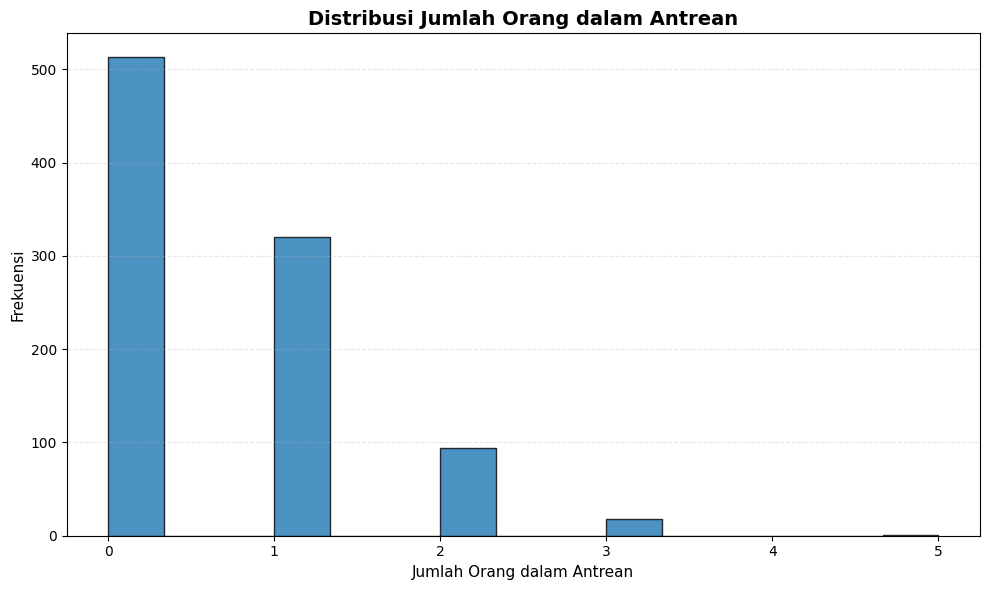

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["queue_size"],
    bins=15,
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribusi Jumlah Orang dalam Antrean",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Jumlah Orang dalam Antrean",
    fontsize=11
)

plt.ylabel(
    "Frekuensi",
    fontsize=11
)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

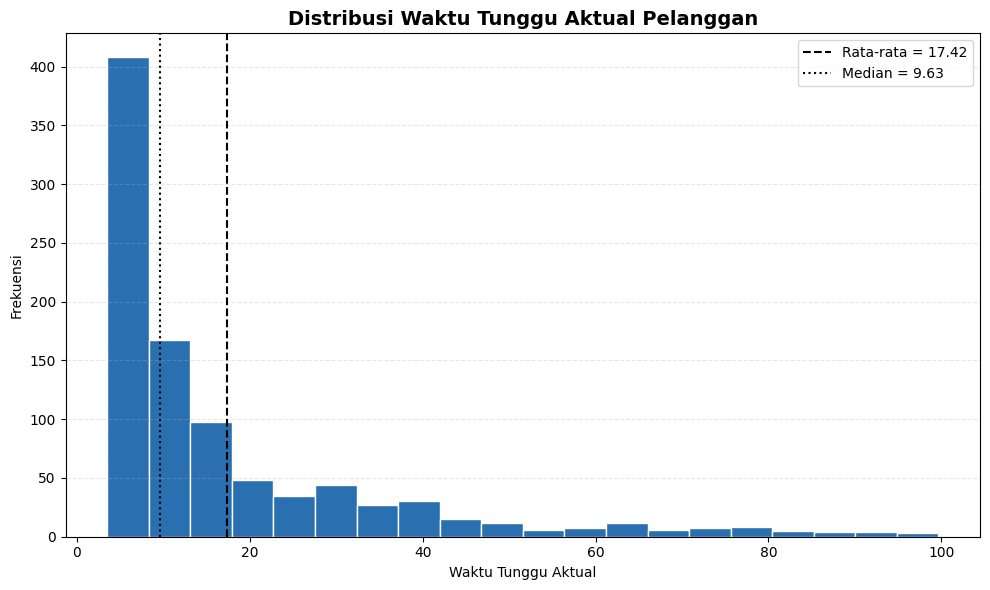

In [17]:
# Histogram actual_wait
rata = df["actual_wait"].mean()
med = df["actual_wait"].median()

plt.figure(figsize=(10, 6))
plt.hist(df["actual_wait"], bins=20, color="#2A6FB0", edgecolor="white")

plt.axvline(rata, color="black", linestyle="--", label=f"Rata-rata = {rata:.2f}")
plt.axvline(med, color="black", linestyle=":", label=f"Median = {med:.2f}")
plt.title("Distribusi Waktu Tunggu Aktual Pelanggan", fontsize=14, fontweight="bold")
plt.xlabel("Waktu Tunggu Aktual")
plt.ylabel("Frekuensi")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

r = -0.006 | p-value = 0.848


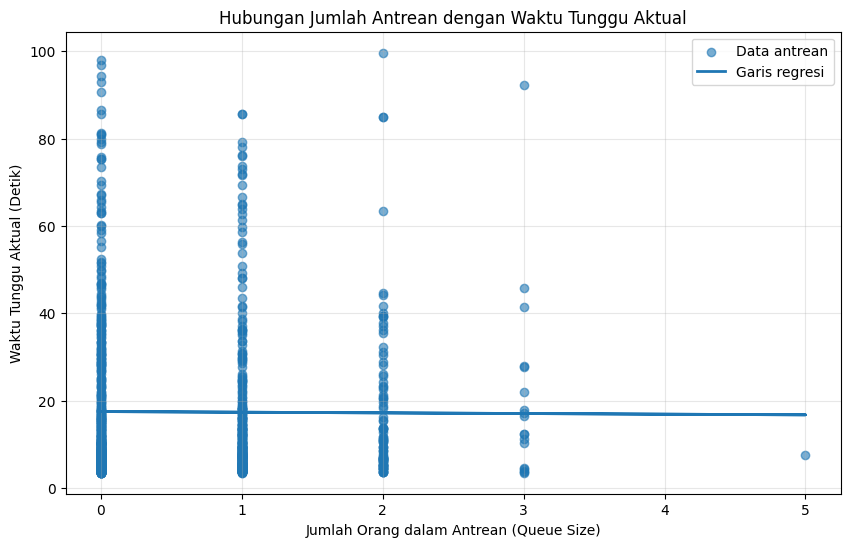

In [22]:
# Mengambil data yang diperlukan
x = df["queue_size"]
y = df["actual_wait"]

# Membuat scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.6,
    label="Data antrean"
)

# Menghitung garis regresi linear
koefisien = np.polyfit(x, y, 1)
garis = np.poly1d(koefisien)

# Membuat garis regresi
plt.plot(
    x,
    garis(x),
    linewidth=2,
    label="Garis regresi"
)

# Judul dan label
plt.title("Hubungan Jumlah Antrean dengan Waktu Tunggu Aktual")
plt.xlabel("Jumlah Orang dalam Antrean (Queue Size)")
plt.ylabel("Waktu Tunggu Aktual (Detik)")

plt.grid(True, alpha=0.3)
plt.legend()
r_q, p_q = stats.pearsonr(df["queue_size"], df["actual_wait"])
print("r =", round(r_q, 3), "| p-value =", round(p_q, 3))
plt.show()

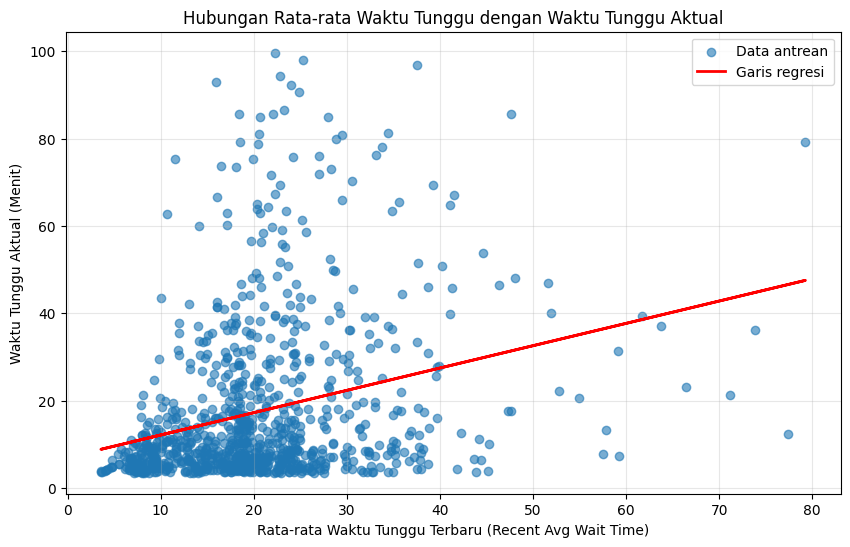

Koefisien korelasi (r): 0.279


In [ ]:
# Scatter plot recent_avg_wait_time vs actual_wait
x = df["recent_avg_wait_time"]
y = df["actual_wait"]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label="Data antrean")

# Garis regresi linear
koefisien = np.polyfit(x, y, 1)
garis = np.poly1d(koefisien)
plt.plot(x, garis(x), color="red", linewidth=2, label="Garis regresi")

plt.title("Hubungan Rata-rata Waktu Tunggu dengan Waktu Tunggu Aktual")
plt.xlabel("Rata-rata Waktu Tunggu Terbaru (Recent Avg Wait Time)")
plt.ylabel("Waktu Tunggu Aktual (Menit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Korelasi
r = x.corr(y)
print("Koefisien korelasi (r):", round(r, 3))